In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [8]:
df = pd.read_csv("HR_analytacis.csv")
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [11]:
X = df[['Age','MonthlyIncome','YearsAtCompany']]
y = df['Attrition']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = RandomForestClassifier()

In [14]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

          Feature  Importance
1   MonthlyIncome    0.535109
0             Age    0.275386
2  YearsAtCompany    0.189505


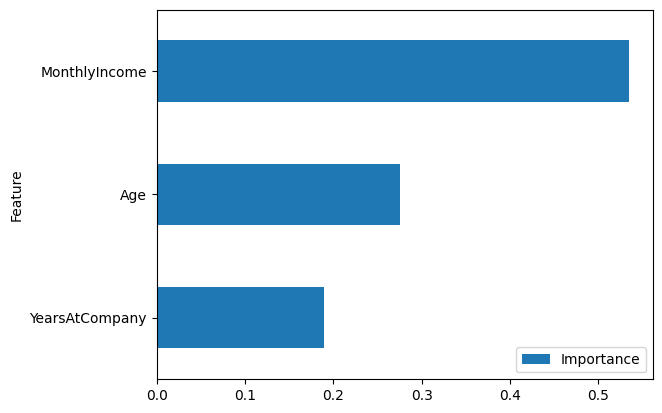

In [22]:
import matplotlib.pyplot as plt

importance.sort_values(by='Importance').plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.show()

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[243  12]
 [ 35   4]]


In [24]:
accuracy_percent = accuracy * 100

print("Model Accuracy:", accuracy_percent,"%")

Model Accuracy: 84.01360544217688 %


In [ ]:
X = df[[
    'Age',
    'MonthlyIncome',
    'YearsAtCompany',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'DistanceFromHome'
]]

In [ ]:
Encode Text Columns 

Gender
Department
JobRole

Use Label Encoding:

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(accuracy_score(y_test, lr_pred))

0.8673469387755102


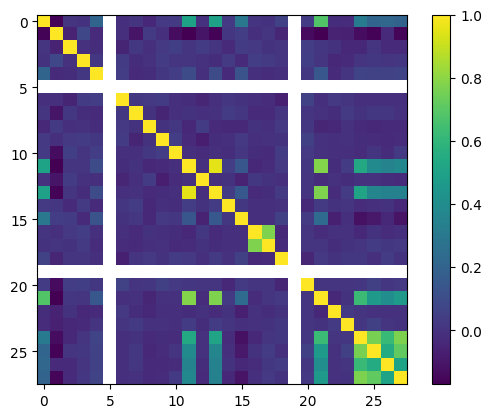

In [29]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()
plt.show()

In [30]:
predictions = model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8401360544217688


In [32]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       255
           1       0.25      0.10      0.15        39

    accuracy                           0.84       294
   macro avg       0.56      0.53      0.53       294
weighted avg       0.79      0.84      0.81       294



In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("HR_analytacis.csv")

df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

X = df[['Age','MonthlyIncome','YearsAtCompany']]
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

new_employee = pd.DataFrame({
    'Age':[30],
    'MonthlyIncome':[4000],
    'YearsAtCompany':[5]
})

prediction = model.predict(new_employee)

if prediction[0] == 1:
    print("Employee may leave the company")
else:
    print("Employee may stay in the company")

Accuracy: 0.8469387755102041
Employee may stay in the company
